In [58]:
"""
Constructs the DFT of the dihedral group in SageMath using knowledge of the representation theory.

""";

In [59]:
# ── Configuration ──────────────────────────────────────────────────────────────
n = 5; print("n =", n)
USE_FINITE_FIELD = False
p = 23; print("p =", p) # characteristic of the finite field
q = 23; print("q =", q) # size of the finite field

n = 5
p = 23
q = 23


In [60]:
# ── Build the coefficient ring and choose omega ─────────────────────────────────
if USE_FINITE_FIELD:
    # Find the smallest k such that n | (q^k - 1),
    # i.e. the multiplicative order of q mod n.
    k = Zmod(n)(q).multiplicative_order()
    F = GF(q**k, 'a')
    print(f"Working in GF({q}^{k}) = GF({q**k})")

    # Find a primitive n-th root of unity in F.
    # The multiplicative group of GF(q^k) is cyclic of order q^k - 1,
    # so a generator g satisfies g^((q^k-1)/n) has order n.
    g = F.multiplicative_generator()
    omega = g**((q**k - 1) // n)
    assert omega**n == F.one(), "omega is not an n-th root of unity"
    assert omega**(n-1) != F.one() or n == 1, "omega is not primitive"
    print(f"omega = {omega}  (order {omega.multiplicative_order()})")
else:
    K.<z> = CyclotomicField(n) #cyclotomic field containing a primitive n-th root of unity
    omega = z; print(f"omega = {omega}  (primitive n-th root of unity)")

omega = z  (primitive n-th root of unity)


In [61]:
G = DihedralGroup(n); print("G =", G) #D_n, dihedral group of order 2n
r = [g for g in G if g.order() == n][0] #rotation of order n, generator
s = [g for g in G if g.order() == 2 and g != r**(n//2)][0] #flip of order 2, generator
print("r =", r)
print("s =", s)

G = Dihedral group of order 10 as a permutation group
r = (1,5,4,3,2)
s = (2,5)(3,4)


In [62]:
# returns (0, k) if g = r^k and (1, k) if g = s*r^k
def express_in_gens(g):
    for k in range(n):
        if g == r**k:
            return (0, k)
    for k in range(n):
        if g == s * r**k:
            return (1, k)

In [63]:
# n odd, we have two 1-dim'l irreps and (n-1)/2 2-dim'l irreps
# the 1-dim's irreps are trivial and sign
# the 2-dim'l irreps are given by rotation matrices and a flip matrix
def rho_odd(k, g, omega):
    (s_exp, r_exp) = express_in_gens(g)
    if k == 0:
        return matrix([1])
    if k == -1:
        if s_exp == 0:
            return matrix([1])
        if s_exp == 1:
            return matrix([-1])
    if k >= 1:
        if s_exp == 0:
            return matrix([[omega**(k*r_exp), 0], [0, omega**(-k*r_exp)]])
        if s_exp == 1:
            return matrix([[0, omega**(k*r_exp)], [omega**(-k*r_exp), 0]])

In [64]:
def dft_matrix_odd(omega):
    assert n % 2 == 1
    rows = []
    for g in G:
        row = [rho_odd(k, g, omega).list() for k in range(-1,(n-1)//2 + 1)]
        rows.append(sum(row, []))
    return matrix(rows)

In [65]:
# for n even case
def rho_even(k, g, omega):
    (s_exp, r_exp) = express_in_gens(g)
    if k == 0:   # trivial
        return matrix([1])
    if k == -1:  # sign of rotation
        return matrix([(-1)**r_exp])
    if k == -2:  # sign of reflection
        return matrix([(-1)**s_exp])
    if k == -3:  # total sign
        return matrix([(-1)**(r_exp + s_exp)])
    if k >= 1:
        if s_exp == 0:
            return matrix([[omega**(k*r_exp), 0], [0, omega**(-k*r_exp)]])
        if s_exp == 1:
            return matrix([[0, omega**(k*r_exp)], [omega**(-k*r_exp), 0]])

In [66]:
# form the DFT matrix for n even
def dft_matrix_even(omega):
    assert n % 2 == 0
    rows = []
    for g in G:
        row = [rho_even(k, g, omega).list() for k in range(-3, n//2)]
        rows.append(sum(row, []))
    return matrix(rows)

In [ ]:
# compute the trace of the DFT matrix using the formula for the entries
def matrix_entries(i, j):
    if j == 0:
        return 1 if i < n else -1
    if j == 1:
        return 1

    k = j - 2
    m = k // 4 + 1
    r = k % 4

    if i < n:
        return omega**(m * i) if r == 0 else omega**(-m * i) if r == 3 else 0
    else:
        return omega**(m * i) if r == 1 else omega**(-m * i) if r == 2 else 0

In [ ]:
# compute the trace of the DFT matrix using the formula for the entries
def trace_dft():
    total = 2
    total += sum(omega**(((i-2)//4+1)*i) for i in range(2, n) if i % 4 == 2)
    total += sum(omega**(-((i-2)//4+1)*i) for i in range(2, n) if i % 4 == 1)
    total += sum(omega**(((i-2)//4+1)*i) for i in range(n, 2*n) if i % 4 == 3)
    total += sum(omega**(-(((i-2)//4+1)*i)) for i in range(n, 2*n) if i % 4 == 0)
    return total

In [71]:
def DFT_matrix_odd_from_entries():
    assert n % 2 == 1
    return matrix(2*n, 2*n, matrix_entries)

In [72]:
matrix([[omega**n,0,0,omega**n],[0,1,1,0],[0,omega,omega,0],[0,omega**2,omega**2,0]])

[  1   0   0   1]
[  0   1   1   0]
[  0   z   z   0]
[  0 z^2 z^2   0]

In [73]:
DFT_matrix_odd_from_entries()

[                 1                  1                  1                  0                  0                  1                  1                  0                  0                  1]
[                 1                  1                  z                  0                  0 -z^3 - z^2 - z - 1                z^2                  0                  0                z^3]
[                 1                  1                z^2                  0                  0                z^3 -z^3 - z^2 - z - 1                  0                  0                  z]
[                 1                  1                z^3                  0                  0                z^2                  z                  0                  0 -z^3 - z^2 - z - 1]
[                 1                  1 -z^3 - z^2 - z - 1                  0                  0                  z                z^3                  0                  0                z^2]
[                -1                  1  

In [74]:
DFT_matrix = dft_matrix_odd(omega) if n % 2 == 1 else dft_matrix_even(omega); print(DFT_matrix)

[                 1                  1                  1                  0                  0                  1                  1                  0                  0                  1]
[                 1                  1                  z                  0                  0 -z^3 - z^2 - z - 1                z^2                  0                  0                z^3]
[                 1                  1                z^2                  0                  0                z^3 -z^3 - z^2 - z - 1                  0                  0                  z]
[                 1                  1                z^3                  0                  0                z^2                  z                  0                  0 -z^3 - z^2 - z - 1]
[                 1                  1 -z^3 - z^2 - z - 1                  0                  0                  z                z^3                  0                  0                z^2]
[                -1                  1  

In [75]:
f = DFT_matrix.charpoly(); print(f)

x^10 + (2*z^3 + z^2 + 2*z)*x^9 + (-5*z^3 - 6*z^2 - 3*z - 1)*x^8 + (12*z^3 + 19*z^2 + 10*z + 4)*x^7 + (-8*z^3 - 23*z^2 - 20*z - 14)*x^6 + (20*z^3 + 40*z^2 - 10*z + 5)*x^5 + (-15*z^3 + 20*z^2 + 5*z + 40)*x^4 + (150*z^3 - 175*z^2 - 350*z - 125)*x^3 + (-1000*z^3 - 500*z^2 + 250*z + 125)*x^2 + (-1250*z^3 - 2500*z - 1250)*x + 6250


In [76]:
if USE_FINITE_FIELD:
    L.<a> = f.splitting_field(); print(L)

In [77]:
if USE_FINITE_FIELD:
    R_L.<x> = PolynomialRing(L)
    f_L = R_L(f)
    f_L.factor()

In [78]:
if USE_FINITE_FIELD:
    eigenvalues = f.roots(L, multiplicities=False)
    print(eigenvalues)
    print(len(eigenvalues))

In [79]:
def frobenius(x, p):
    return x**p

In [80]:
def frobenius_orbit(alpha, p):
    orbit = []
    seen = set()
    
    x = alpha
    while x not in seen:
        seen.add(x)
        orbit.append(x)
        x = x^p
    
    return orbit

In [81]:
def frobenius_orbits(eigenvalues, p):
    orbits = []
    seen = set()
    
    for lam in eigenvalues:
        if lam not in seen:
            orb = frobenius_orbit(lam, p)
            orbits.append(orb)
            seen.update(orb)
    
    return orbits

In [82]:
def discrete_log_Fq(x, alpha=None):
    F = x.parent()
    if x == 0:
        raise ValueError("Log undefined for 0")
    if alpha is None:
        alpha = F.multiplicative_generator()
    return x.log(alpha)

In [83]:
frobenius_orbits(eigenvalues, p)

NameError: name 'eigenvalues' is not defined

In [ ]:
len(frobenius_orbit(eigenvalues[0], p))

10

In [ ]:
dlogs = [discrete_log_Fq(x, alpha=None) for x in eigenvalues]; dlogs

[22535256581237,
 13787918735573,
 1490726729279,
 1138953522821,
 2743037516069,
 31742013157397]

In [ ]:
def brauer_map(x):
    if x == 0:
        return 0
    else:
        l = discrete_log_Fq(x, alpha=None)
        return exp(2 * pi * I * l / (L.order()-1))

In [ ]:
complex_eigs = [brauer_map(eig) for eig in eigenvalues]; complex_eigs
eigs_num = [complex(e.n(digits=30)) for e in complex_eigs]; eigs_num

[(-0.9620593566641997-0.2728402357697012j),
 (-0.4972498516726871+0.8676073910539782j),
 (0.9745482188969931+0.22417798519189705j),
 (0.98511651032388+0.1718879317674766j),
 (0.914697217451556+0.40413982776556556j),
 (0.1017658697630646-0.9948083774030891j)]

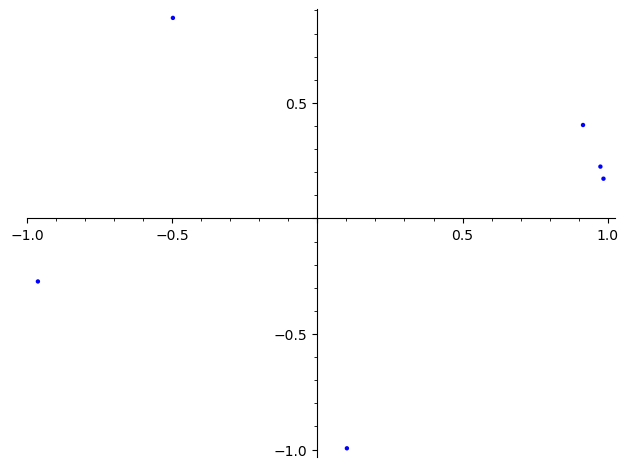

In [ ]:
P = list_plot(
    [(z.real, z.imag) for z in eigs_num],
    plotjoined=False,
    marker='o'
)

P.show()

In [ ]:
# can normalize by 1/sqrt(D) to get a unitary matrix
if not USE_FINITE_FIELD:
    print(DFT_matrix.conjugate_transpose() * DFT_matrix)

[10  0  0  0  0  0  0  0  0  0]
[ 0 10  0  0  0  0  0  0  0  0]
[ 0  0  5  0  0  0  0  0  0  0]
[ 0  0  0  5  0  0  0  0  0  0]
[ 0  0  0  0  5  0  0  0  0  0]
[ 0  0  0  0  0  5  0  0  0  0]
[ 0  0  0  0  0  0  5  0  0  0]
[ 0  0  0  0  0  0  0  5  0  0]
[ 0  0  0  0  0  0  0  0  5  0]
[ 0  0  0  0  0  0  0  0  0  5]


In [ ]:
# form norm polynomial by acting on coefficients of characteristic polynomial by the Galois group
def norm_poly(f, n):

    def sigma(i):
        phi = K.hom([z**i])
        return f.map_coefficients(phi)
    
    units = [i for i in range(1, n) if gcd(i, n) == 1]  # (Z/nZ)^×
    result = prod(sigma(i) for i in units)
    return result.change_ring(QQ)

In [ ]:
f = DFT_matrix.charpoly(); f

x^10 + (2*z^3 + z^2 + 2*z)*x^9 + (-5*z^3 - 6*z^2 - 3*z - 1)*x^8 + (12*z^3 + 19*z^2 + 10*z + 4)*x^7 + (-8*z^3 - 23*z^2 - 20*z - 14)*x^6 + (20*z^3 + 40*z^2 - 10*z + 5)*x^5 + (-15*z^3 + 20*z^2 + 5*z + 40)*x^4 + (150*z^3 - 175*z^2 - 350*z - 125)*x^3 + (-1000*z^3 - 500*z^2 + 250*z + 125)*x^2 + (-1250*z^3 - 2500*z - 1250)*x + 6250

In [ ]:
if not USE_FINITE_FIELD:
    Nf = norm_poly(f, n); Nf

In [ ]:
if not USE_FINITE_FIELD:
    Nf.is_irreducible()

In [ ]:
if not USE_FINITE_FIELD:
    Nf.factor()

In [ ]:
if not USE_FINITE_FIELD:
    Nf.galois_group()

NotImplementedError: Galois group computation is supported for degrees up to 11 using PARI, or up to 21 if KASH is installed.  Try algorithm='magma' if you have magma.

In [ ]:
if not USE_FINITE_FIELD:
    G = TransitiveGroup(12, 299)
    print(G.order())
    print(G.is_solvable())
    print(G.is_primitive())
    print(G.structure_description())

1036800
False
False
(A6 x A6) : D4
